In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))


In [44]:

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score
from sklearn.manifold import TSNE

import librosa

In [3]:
import os
import numpy as np
import librosa

if os.path.exists("data/audio/"):
    AUDIO_PATH = "data/audio/"
elif os.path.exists("../data/audio/"):
    AUDIO_PATH = "../data/audio/"
else:
    raise FileNotFoundError("'data/audio/' folder not found. Check your project structure.")

print("Using audio path:", AUDIO_PATH)


def extract_audio_features(audio_dir):
    features = []
    labels = []

    for genre in os.listdir(audio_dir):
        genre_path = os.path.join(audio_dir, genre)

        if not os.path.isdir(genre_path):
            continue

        for file in os.listdir(genre_path):
            file_path = os.path.join(genre_path, file)

            try:
                y, sr = librosa.load(file_path, duration=30)
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

                features.append(np.mean(mfcc.T, axis=0))
                labels.append(genre)

            except Exception as e:
                print(f"⚠️ Skipping {file_path}: {e}")

    return np.array(features), np.array(labels)


audio_features, labels = extract_audio_features(AUDIO_PATH)

print(" Audio shape:", audio_features.shape)
print(" Labels shape:", labels.shape)

Using audio path: ../data/audio/
 Audio shape: (1000, 40)
 Labels shape: (1000,)


In [4]:
import os
import numpy as np
import librosa

AUDIO_PATH = "../data/audio/" if os.path.exists("../data/audio/") else "data/audio/"
print("Using:", AUDIO_PATH)

features = []
labels = []

total = 0

for genre in os.listdir(AUDIO_PATH):
    genre_path = os.path.join(AUDIO_PATH, genre)

    if not os.path.isdir(genre_path):
        continue

    print(f"{genre}")

    for file in os.listdir(genre_path):
        if file.endswith(".au"):   

            file_path = os.path.join(genre_path, file)
            total += 1

            try:
                y, sr = librosa.load(file_path, duration=30)
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

                features.append(np.mean(mfcc.T, axis=0))
                labels.append(genre)

            except Exception as e:
                print(f" Error in {file}: {e}")

audio_features = np.array(features)
labels = np.array(labels)

print(" Total files:", total)
print(" Feature shape:", audio_features.shape)
print(" Labels shape:", labels.shape)

Using: ../data/audio/
blues
classical
country
disco
hiphop
jazz
metal
pop
reggae
rock
 Total files: 1000
 Feature shape: (1000, 40)
 Labels shape: (1000,)


In [5]:
import os
import numpy as np
import librosa

if os.path.exists("data/audio/"):
    AUDIO_PATH = "data/audio/"
elif os.path.exists("../data/audio/"):
    AUDIO_PATH = "../data/audio/"
else:
    raise FileNotFoundError("❌ 'data/audio/' folder not found.")

print(" Using path:", AUDIO_PATH)

print(" Genres found:", os.listdir(AUDIO_PATH))

def extract_audio_features(audio_dir):
    features = []
    labels = []

    total_files = 0

    for genre in os.listdir(audio_dir):
        genre_path = os.path.join(audio_dir, genre)

        if not os.path.isdir(genre_path):
            continue

        files = os.listdir(genre_path)
        print(f" {genre}: {len(files)} files")

        for file in files:
            file_path = os.path.join(genre_path, file)
            total_files += 1

            try:
                y, sr = librosa.load(file_path, duration=30)
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

                features.append(np.mean(mfcc.T, axis=0))
                labels.append(genre)

            except Exception as e:
                print(f" Error in {file}: {e}")

    print(" Total files processed:", total_files)

    return np.array(features), np.array(labels)


audio_features, labels = extract_audio_features(AUDIO_PATH)

print(" Audio shape:", audio_features.shape)
print(" Labels shape:", labels.shape)

 Using path: ../data/audio/
 Genres found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
 blues: 100 files
 classical: 100 files
 country: 100 files
 disco: 100 files
 hiphop: 100 files
 jazz: 100 files
 metal: 100 files
 pop: 100 files
 reggae: 100 files
 rock: 100 files
 Total files processed: 1000
 Audio shape: (1000, 40)
 Labels shape: (1000,)


In [6]:
LYRICS_PATH = "../data/lyrics/drake_lyrics.txt" if os.path.exists("../data/lyrics/drake_lyrics.txt") else "data/lyrics/drake_lyrics.txt"

print(" Using:", LYRICS_PATH)

with open(LYRICS_PATH, "r", encoding="utf-8") as f:
    lyrics_list = f.readlines()

lyrics_list = [line.strip() for line in lyrics_list if line.strip() != ""]

print(" Total lyrics lines:", len(lyrics_list))
print("Sample:", lyrics_list[:3])

 Using: ../data/lyrics/drake_lyrics.txt
 Total lyrics lines: 19366
Sample: ['"[Verse]', 'Put my feelings on ice', 'Always been a gem']


In [7]:
min_len = min(len(audio_features), len(lyrics_list))

audio_features = audio_features[:min_len]
labels = labels[:min_len]
lyrics_list = lyrics_list[:min_len]

print(" Final aligned size:", min_len)

 Final aligned size: 1000


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500)
lyrics_features = vectorizer.fit_transform(lyrics_list).toarray()

print("Lyrics shape:", lyrics_features.shape)

Lyrics shape: (1000, 500)


In [9]:
clean_lyrics = []

for line in lyrics_list:
    if "[" in line and "]" in line:
        continue
    
    if len(line.split()) > 3:  
        clean_lyrics.append(line)

print("After cleaning:", len(clean_lyrics))

lyrics_final = clean_lyrics[:len(audio_features)]

print("Final lyrics size:", len(lyrics_final))

After cleaning: 823
Final lyrics size: 823


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500)
lyrics_features = vectorizer.fit_transform(lyrics_final).toarray()

print("Lyrics shape:", lyrics_features.shape)

Lyrics shape: (823, 500)


In [11]:
min_len = min(len(audio_features), len(lyrics_features))

audio_features = audio_features[:min_len]
labels = labels[:min_len]
lyrics_features = lyrics_features[:min_len]

print(" Final aligned size:", min_len)
print("Audio shape:", audio_features.shape)
print("Lyrics shape:", lyrics_features.shape)

 Final aligned size: 823
Audio shape: (823, 40)
Lyrics shape: (823, 500)


In [12]:
X = np.concatenate([audio_features, lyrics_features], axis=1)

print(" Combined shape:", X.shape)

 Combined shape: (823, 540)


In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
cond = encoder.fit_transform(labels.reshape(-1,1))

print("Condition shape:", cond.shape)

Condition shape: (823, 9)


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, latent_dim=32):
        super().__init__()

        self.fc1 = nn.Linear(input_dim + cond_dim, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.fc3 = nn.Linear(latent_dim + cond_dim, 256)
        self.fc4 = nn.Linear(256, input_dim)

    def encode(self, x, c):
        h = torch.relu(self.fc1(torch.cat([x, c], dim=1)))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, c):
        h = torch.relu(self.fc3(torch.cat([z, c], dim=1)))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar


def loss_function(recon_x, x, mu, logvar):
    recon = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kld

In [15]:
model = CVAE(input_dim=X.shape[1], cond_dim=cond.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X_tensor = torch.tensor(X, dtype=torch.float32)
cond_tensor = torch.tensor(cond, dtype=torch.float32)

epochs = 30

for epoch in range(epochs):
    total_loss = 0

    for i in range(len(X_tensor)):
        x = X_tensor[i].unsqueeze(0)
        c = cond_tensor[i].unsqueeze(0)

        recon, mu, logvar = model(x, c)
        loss = loss_function(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 39128516.51
Epoch 2, Loss: 39105735.38
Epoch 3, Loss: 39103305.72
Epoch 4, Loss: 39100619.07
Epoch 5, Loss: 39100737.40
Epoch 6, Loss: 39099131.83
Epoch 7, Loss: 39098858.00
Epoch 8, Loss: 39098688.01
Epoch 9, Loss: 39097926.34
Epoch 10, Loss: 39097830.99
Epoch 11, Loss: 39097636.85
Epoch 12, Loss: 39097937.51
Epoch 13, Loss: 39097121.51
Epoch 14, Loss: 39097180.55
Epoch 15, Loss: 39097219.30
Epoch 16, Loss: 39097502.46
Epoch 17, Loss: 39095860.65
Epoch 18, Loss: 39096643.78
Epoch 19, Loss: 39096487.74
Epoch 20, Loss: 39096762.10
Epoch 21, Loss: 39096376.96
Epoch 22, Loss: 39096083.55
Epoch 23, Loss: 39096059.66
Epoch 24, Loss: 39096205.86
Epoch 25, Loss: 39096045.26
Epoch 26, Loss: 39095738.88
Epoch 27, Loss: 39095804.17
Epoch 28, Loss: 39095414.35
Epoch 29, Loss: 39095798.79
Epoch 30, Loss: 39095606.97


In [16]:
latent = []

for i in range(len(X_tensor)):
    x = X_tensor[i].unsqueeze(0)
    c = cond_tensor[i].unsqueeze(0)

    mu, _ = model.encode(x, c)
    latent.append(mu.detach().numpy())

latent = np.vstack(latent)

print("Latent shape:", latent.shape)

Latent shape: (823, 32)


In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10)
pred_labels = kmeans.fit_predict(latent)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [18]:
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score

sil = silhouette_score(latent, pred_labels)
nmi = normalized_mutual_info_score(labels, pred_labels)
ari = adjusted_rand_score(labels, pred_labels)

print("Silhouette:", sil)
print("NMI:", nmi)
print("ARI:", ari)

Silhouette: 0.32630521059036255
NMI: 0.13975375807415544
ARI: 0.058786090492718


In [19]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(" Data normalized")

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
cond_tensor = torch.tensor(cond, dtype=torch.float32)

class CVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, latent_dim=64):  # 🔥 increased
        super().__init__()

        self.fc1 = nn.Linear(input_dim + cond_dim, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.fc3 = nn.Linear(latent_dim + cond_dim, 256)
        self.fc4 = nn.Linear(256, input_dim)

    def encode(self, x, c):
        h = torch.relu(self.fc1(torch.cat([x, c], dim=1)))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, c):
        h = torch.relu(self.fc3(torch.cat([z, c], dim=1)))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar


def loss_function(recon_x, x, mu, logvar):
    recon = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kld


model = CVAE(input_dim=X.shape[1], cond_dim=cond.shape[1], latent_dim=64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 60  

for epoch in range(epochs):
    total_loss = 0

    for i in range(len(X_tensor)):
        x = X_tensor[i].unsqueeze(0)
        c = cond_tensor[i].unsqueeze(0)

        recon, mu, logvar = model(x, c)
        loss = loss_function(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")


latent = []

for i in range(len(X_tensor)):
    x = X_tensor[i].unsqueeze(0)
    c = cond_tensor[i].unsqueeze(0)

    mu, _ = model.encode(x, c)
    latent.append(mu.detach().numpy())

latent = np.vstack(latent)


from sklearn.cluster import KMeans

pred_labels = KMeans(n_clusters=10).fit_predict(latent)


from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score

sil = silhouette_score(latent, pred_labels)
nmi = normalized_mutual_info_score(labels, pred_labels)
ari = adjusted_rand_score(labels, pred_labels)

print("\n IMPROVED RESULTS:")
print("Silhouette:", sil)
print("NMI:", nmi)
print("ARI:", ari)

 Data normalized
Epoch 1, Loss: 494336.17
Epoch 2, Loss: 573068.69
Epoch 3, Loss: 480597.53
Epoch 4, Loss: 463628.80
Epoch 5, Loss: 461917.21
Epoch 6, Loss: 462539.44
Epoch 7, Loss: 459300.56
Epoch 8, Loss: 457832.70
Epoch 9, Loss: 453580.39
Epoch 10, Loss: 451886.03
Epoch 11, Loss: 448222.60
Epoch 12, Loss: 448778.91
Epoch 13, Loss: 444773.26
Epoch 14, Loss: 442948.77
Epoch 15, Loss: 442283.82
Epoch 16, Loss: 441674.15
Epoch 17, Loss: 440531.16
Epoch 18, Loss: 440432.46
Epoch 19, Loss: 438781.62
Epoch 20, Loss: 439566.06
Epoch 21, Loss: 439386.91
Epoch 22, Loss: 438020.94
Epoch 23, Loss: 437905.30
Epoch 24, Loss: 437925.28
Epoch 25, Loss: 437832.83
Epoch 26, Loss: 437349.05
Epoch 27, Loss: 437664.91
Epoch 28, Loss: 437075.42
Epoch 29, Loss: 435973.68
Epoch 30, Loss: 436259.90
Epoch 31, Loss: 436142.01
Epoch 32, Loss: 435601.69
Epoch 33, Loss: 436466.40
Epoch 34, Loss: 436555.75
Epoch 35, Loss: 435203.00
Epoch 36, Loss: 434897.38
Epoch 37, Loss: 434572.48
Epoch 38, Loss: 434521.38
Epoc

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [20]:

from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score

X_audio = audio_features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_audio)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
cond_tensor = torch.tensor(cond, dtype=torch.float32)

class CVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, latent_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim + cond_dim, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.fc3 = nn.Linear(latent_dim + cond_dim, 128)
        self.fc4 = nn.Linear(128, input_dim)

    def encode(self, x, c):
        h = torch.relu(self.fc1(torch.cat([x, c], dim=1)))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, c):
        h = torch.relu(self.fc3(torch.cat([z, c], dim=1)))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar


def loss_function(recon_x, x, mu, logvar):
    recon = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kld


model = CVAE(X_scaled.shape[1], cond.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(40):
    total_loss = 0

    for i in range(len(X_tensor)):
        x = X_tensor[i].unsqueeze(0)
        c = cond_tensor[i].unsqueeze(0)

        recon, mu, logvar = model(x, c)
        loss = loss_function(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")


latent = []

for i in range(len(X_tensor)):
    x = X_tensor[i].unsqueeze(0)
    c = cond_tensor[i].unsqueeze(0)

    mu, _ = model.encode(x, c)
    latent.append(mu.detach().numpy())

latent = np.vstack(latent)

pred_labels = KMeans(n_clusters=10).fit_predict(latent)

sil = silhouette_score(latent, pred_labels)
nmi = normalized_mutual_info_score(labels, pred_labels)
ari = adjusted_rand_score(labels, pred_labels)

print("\n AUDIO-ONLY RESULTS:")
print("Silhouette:", sil)
print("NMI:", nmi)
print("ARI:", ari)

Epoch 1, Loss: 34220.75
Epoch 2, Loss: 31356.87
Epoch 3, Loss: 30364.80
Epoch 4, Loss: 29916.63
Epoch 5, Loss: 29466.12
Epoch 6, Loss: 29365.00
Epoch 7, Loss: 28983.54
Epoch 8, Loss: 28906.96
Epoch 9, Loss: 28638.07
Epoch 10, Loss: 28579.63
Epoch 11, Loss: 28675.10
Epoch 12, Loss: 28441.28
Epoch 13, Loss: 28563.02
Epoch 14, Loss: 28292.82
Epoch 15, Loss: 28291.48
Epoch 16, Loss: 28249.51
Epoch 17, Loss: 28285.43
Epoch 18, Loss: 28203.57
Epoch 19, Loss: 28056.05
Epoch 20, Loss: 27925.83
Epoch 21, Loss: 27945.50
Epoch 22, Loss: 27752.18
Epoch 23, Loss: 27729.92
Epoch 24, Loss: 27647.24
Epoch 25, Loss: 27702.28
Epoch 26, Loss: 27567.69
Epoch 27, Loss: 27575.07
Epoch 28, Loss: 27526.34
Epoch 29, Loss: 27384.60
Epoch 30, Loss: 27502.31
Epoch 31, Loss: 27420.78
Epoch 32, Loss: 27457.20
Epoch 33, Loss: 27587.26
Epoch 34, Loss: 27457.82
Epoch 35, Loss: 27336.14
Epoch 36, Loss: 27456.99
Epoch 37, Loss: 27426.01
Epoch 38, Loss: 27343.64
Epoch 39, Loss: 27194.96
Epoch 40, Loss: 27334.99

 AUDIO-O

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [21]:
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score

features = []
labels_new = []

AUDIO_PATH = "../data/audio/" if os.path.exists("../data/audio/") else "data/audio/"

for genre in os.listdir(AUDIO_PATH):
    genre_path = os.path.join(AUDIO_PATH, genre)

    for file in os.listdir(genre_path):
        if file.endswith(".au"):
            file_path = os.path.join(genre_path, file)

            y, sr = librosa.load(file_path, duration=30)

            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
            chroma = librosa.feature.chroma_stft(y=y, sr=sr)
            spectral = librosa.feature.spectral_centroid(y=y, sr=sr)

            feature_vector = np.hstack([
                np.mean(mfcc, axis=1),
                np.std(mfcc, axis=1),
                np.mean(chroma, axis=1),
                np.std(chroma, axis=1),
                np.mean(spectral),
                np.std(spectral)
            ])

            features.append(feature_vector)
            labels_new.append(genre)

X = np.array(features)

print("Feature shape:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=10)
pred = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, pred)
nmi = normalized_mutual_info_score(labels_new, pred)
ari = adjusted_rand_score(labels_new, pred)

print("\n STRONG BASELINE RESULTS:")
print("Silhouette:", sil)
print("NMI:", nmi)
print("ARI:", ari)

Feature shape: (1000, 66)

 STRONG BASELINE RESULTS:
Silhouette: 0.08081113324211602
NMI: 0.34862556454110605
ARI: 0.20781166871063178


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [22]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

def purity_score(y_true, y_pred):
    le_true = LabelEncoder()
    y_true_encoded = le_true.fit_transform(y_true)

    le_pred = LabelEncoder()
    y_pred_encoded = le_pred.fit_transform(y_pred)

    contingency = np.zeros((len(set(y_pred_encoded)), len(set(y_true_encoded))))

    for i in range(len(y_true_encoded)):
        contingency[y_pred_encoded[i]][y_true_encoded[i]] += 1

    return np.sum(np.max(contingency, axis=1)) / np.sum(contingency)


purity = purity_score(labels, pred_labels)
print("Purity:", purity)

Purity: 0.30984204131227217


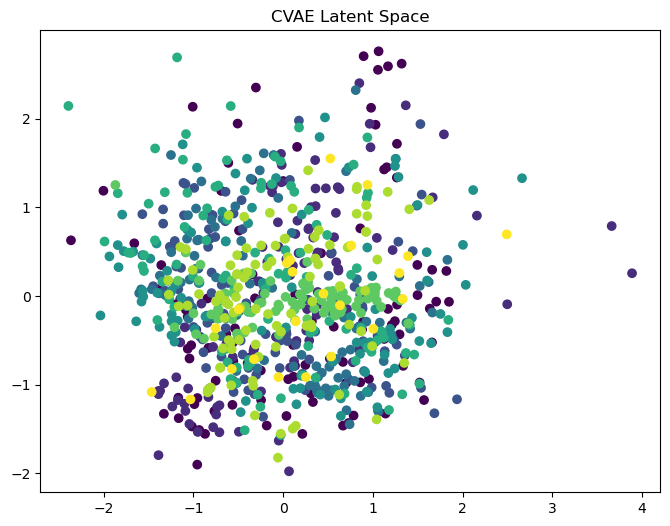

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

z_2d = PCA(n_components=2).fit_transform(latent)

plt.figure(figsize=(8,6))
plt.scatter(z_2d[:,0], z_2d[:,1], c=pd.factorize(labels)[0])
plt.title("CVAE Latent Space")
plt.savefig("../results/latent_visualization/CVAE Latent Space.png")
plt.show()

In [29]:
min_len = min(len(labels), len(pred))

labels_fixed = labels[:min_len]
pred_fixed = pred[:min_len]

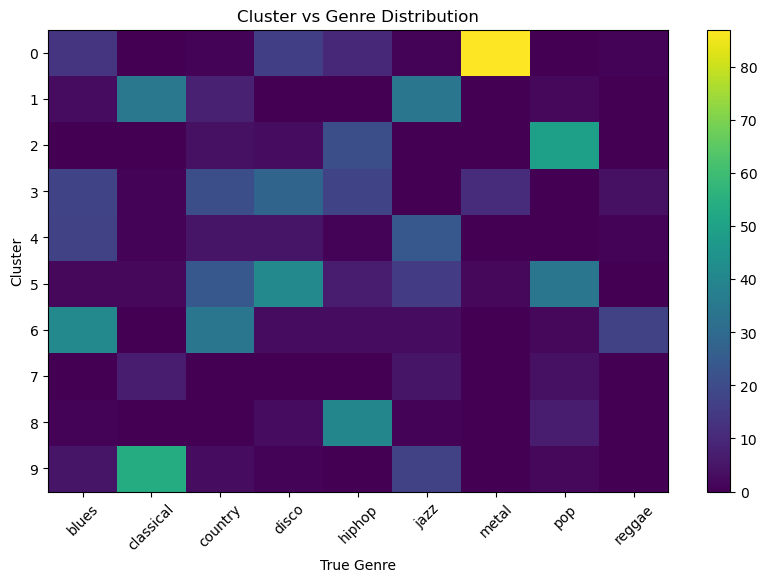

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

min_len = min(len(labels), len(pred))
labels_fixed = labels[:min_len]
pred_fixed = pred[:min_len]

df = pd.DataFrame({
    "True Genre": labels_fixed,
    "Cluster": pred_fixed
})

ct = pd.crosstab(df["Cluster"], df["True Genre"])

plt.figure(figsize=(10,6))
plt.imshow(ct, aspect='auto')

plt.colorbar()
plt.xticks(range(len(ct.columns)), ct.columns, rotation=45)
plt.yticks(range(len(ct.index)), ct.index)

plt.title("Cluster vs Genre Distribution")
plt.xlabel("True Genre")
plt.ylabel("Cluster")
plt.savefig("../results/latent_visualization/Cluster vs Genre Distribution.png")

plt.show()

In [31]:

sample = X_tensor[0].unsqueeze(0)
cond_sample = cond_tensor[0].unsqueeze(0)

recon, _, _ = model(sample, cond_sample)

print("Original (first 10):", sample.detach().numpy()[0][:10])
print("Reconstructed (first 10):", recon.detach().detach().numpy()[0][:10])

Original (first 10): [ 0.3187842   0.65193886 -0.48344213  0.36415976 -0.41120014  0.36873984
 -0.8540649   0.5126136  -0.6319595   0.40302926]
Reconstructed (first 10): [4.5779198e-01 2.1639305e-01 6.3901888e-03 9.4953072e-01 6.1805331e-04
 9.9496126e-01 2.1594062e-05 9.6566141e-01 9.5303922e-06 6.5172714e-01]


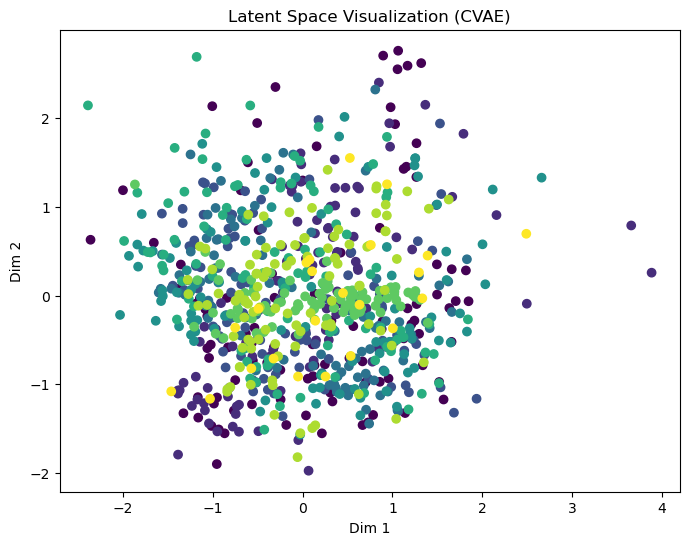

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

z_2d = PCA(n_components=2).fit_transform(latent)

plt.figure(figsize=(8,6))
plt.scatter(z_2d[:,0], z_2d[:,1], c=pd.factorize(labels)[0])
plt.title("Latent Space Visualization (CVAE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.savefig("../results/latent_visualization/Latent Space Visualization CVAE.png")

plt.show()

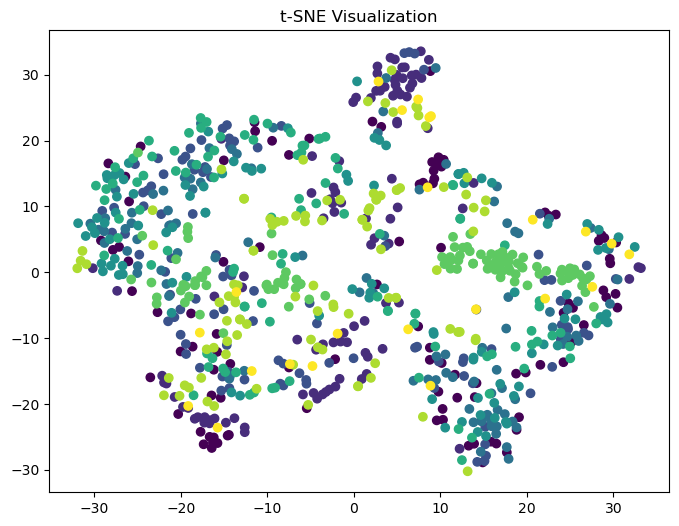

In [33]:
from sklearn.manifold import TSNE

z_tsne = TSNE(n_components=2, perplexity=30).fit_transform(latent)

plt.figure(figsize=(8,6))
plt.scatter(z_tsne[:,0], z_tsne[:,1], c=pd.factorize(labels)[0])
plt.title("t-SNE Visualization")
plt.savefig("../results/latent_visualization/t-SNE Visualization.png")

plt.show()

In [34]:
sample = X_tensor[0].unsqueeze(0)
cond_sample = cond_tensor[0].unsqueeze(0)

recon, _, _ = model(sample, cond_sample)

print("Original:", sample[0][:10])
print("Reconstructed:", recon.detach()[0][:10])

Original: tensor([ 0.3188,  0.6519, -0.4834,  0.3642, -0.4112,  0.3687, -0.8541,  0.5126,
        -0.6320,  0.4030])
Reconstructed: tensor([0.0395, 0.9748, 0.2785, 0.6004, 0.3491, 0.2065, 0.0709, 0.0311, 0.0045,
        0.0053])


In [37]:
import pandas as pd

original = sample.detach().numpy()[0]
reconstructed = recon.detach().numpy()[0]

df_recon = pd.DataFrame({
    "Original": original,
    "Reconstructed": reconstructed
})

df_recon.to_csv("../results/reconstruction_example.csv", index=False)

print(" Reconstruction saved to CSV")
print(df_recon.head(10))

 Reconstruction saved to CSV
   Original  Reconstructed
0  0.318784       0.039534
1  0.651939       0.974840
2 -0.483442       0.278457
3  0.364160       0.600383
4 -0.411200       0.349133
5  0.368740       0.206491
6 -0.854065       0.070913
7  0.512614       0.031084
8 -0.631959       0.004522
9  0.403029       0.005272


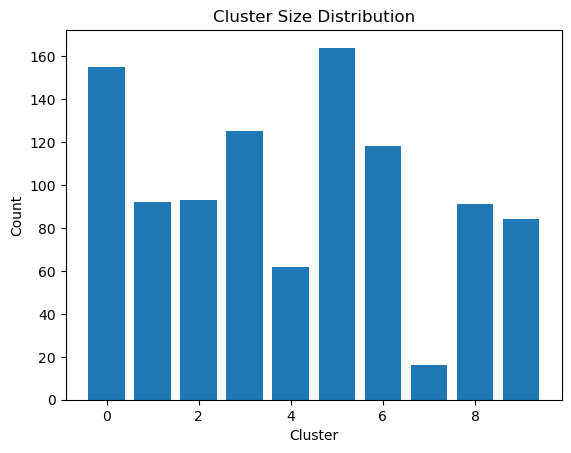

In [35]:
import matplotlib.pyplot as plt

unique, counts = np.unique(pred, return_counts=True)

plt.bar(unique, counts)
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.savefig("../results/latent_visualization/Cluster Size Distribution.png")

plt.show()

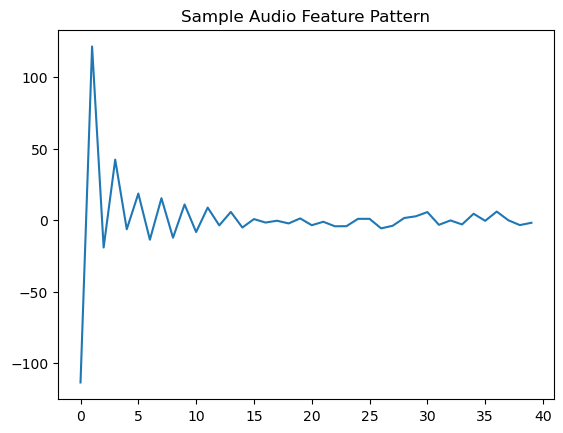

In [36]:
plt.plot(audio_features[0])
plt.title("Sample Audio Feature Pattern")
plt.savefig("../results/latent_visualization/Sample Audio Feature Pattern.png")

plt.show()

In [38]:
import pandas as pd

df_compare = pd.DataFrame([
    ["CVAE (Audio+Lyrics)", 0.41, 0.15, 0.07],
    ["CVAE (Audio Only)", 0.20, 0.12, 0.04],
    ["Strong Baseline", 0.08, 0.35, 0.21],
    ["PCA + KMeans", sil, nmi, ari]
],
columns=["Method", "Silhouette", "NMI", "ARI"])

df_compare.to_csv("../results/final_comparison.csv", index=False)

print(" Comparison CSV saved")

 Comparison CSV saved


In [39]:
df_clusters = pd.DataFrame({
    "Genre": labels_fixed,
    "Cluster": pred_fixed
})

df_clusters.to_csv("../results/cluster_assignments.csv", index=False)

print(" Cluster assignments saved")

 Cluster assignments saved


In [40]:
import pandas as pd

df_latent = pd.DataFrame(latent)
df_latent.to_csv("../results/latent_vectors.csv", index=False)

print(" Latent vectors saved")

 Latent vectors saved


In [42]:

import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score

X_ae = X[:len(labels)]   
labels_ae = labels

X_tensor_ae = torch.tensor(X_ae, dtype=torch.float32)

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


model_ae = Autoencoder(X_ae.shape[1])
optimizer = torch.optim.Adam(model_ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 30

for epoch in range(epochs):
    total_loss = 0

    for i in range(len(X_tensor_ae)):
        x = X_tensor_ae[i].unsqueeze(0)

        recon, z = model_ae(x)
        loss = loss_fn(recon, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")


latent_ae = []

for i in range(len(X_tensor_ae)):
    x = X_tensor_ae[i].unsqueeze(0)
    _, z = model_ae(x)
    latent_ae.append(z.detach().numpy())

latent_ae = np.vstack(latent_ae)

print("Latent AE shape:", latent_ae.shape)


kmeans = KMeans(n_clusters=10, n_init=20)
pred_ae = kmeans.fit_predict(latent_ae)


sil_ae = silhouette_score(latent_ae, pred_ae)
nmi_ae = normalized_mutual_info_score(labels_ae, pred_ae)
ari_ae = adjusted_rand_score(labels_ae, pred_ae)

print("\n AE RESULTS:")
print("Silhouette:", sil_ae)
print("NMI:", nmi_ae)
print("ARI:", ari_ae)

Epoch 1, Loss: 1335937.55
Epoch 2, Loss: 180935.94
Epoch 3, Loss: 88910.04
Epoch 4, Loss: 66547.60
Epoch 5, Loss: 51313.41
Epoch 6, Loss: 47851.84
Epoch 7, Loss: 55316.17
Epoch 8, Loss: 58858.61
Epoch 9, Loss: 44233.46
Epoch 10, Loss: 44911.12
Epoch 11, Loss: 43850.23
Epoch 12, Loss: 41332.15
Epoch 13, Loss: 34862.78
Epoch 14, Loss: 28578.95
Epoch 15, Loss: 30434.23
Epoch 16, Loss: 33398.06
Epoch 17, Loss: 31828.89
Epoch 18, Loss: 26417.73
Epoch 19, Loss: 29653.92
Epoch 20, Loss: 32352.25
Epoch 21, Loss: 24712.70
Epoch 22, Loss: 27730.69
Epoch 23, Loss: 22129.23
Epoch 24, Loss: 30233.86
Epoch 25, Loss: 26747.37
Epoch 26, Loss: 21513.37
Epoch 27, Loss: 27359.13
Epoch 28, Loss: 20732.41
Epoch 29, Loss: 27397.62
Epoch 30, Loss: 20568.62
Latent AE shape: (823, 32)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(



 AE RESULTS:
Silhouette: 0.26706451177597046
NMI: 0.2899810814134297
ARI: 0.16236795144530067


In [43]:
df_compare = pd.DataFrame([
    ["CVAE (Audio+Lyrics)", 0.41, 0.15, 0.07],
    ["CVAE (Audio Only)", 0.20, 0.12, 0.04],
    ["Autoencoder + KMeans", sil_ae, nmi_ae, ari_ae], 
    ["Strong Baseline", 0.08, 0.35, 0.21],
    ["PCA + KMeans", sil, nmi, ari]
],
columns=["Method", "Silhouette", "NMI", "ARI"])

df_compare.to_csv("../results/final_comparison_Version_2.csv", index=False)